In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, ParameterGrid, HalvingGridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, classification_report, roc_auc_score, make_scorer, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib


c:\Code\car-valuation\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
cars = pd.read_csv('../datasets/ml_410k.csv')

In [3]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand               413290 non-null  str    
 1   name                413290 non-null  str    
 2   bodyType            413290 non-null  str    
 3   color               413290 non-null  str    
 4   fuelType            413290 non-null  str    
 5   year                413290 non-null  int64  
 6   mileage             413290 non-null  float64
 7   transmission        413290 non-null  str    
 8   power               413290 non-null  float64
 9   price               413290 non-null  int64  
 10  engineDisplacement  413290 non-null  float64
 11  location            413290 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 37.8 MB


In [4]:
cars['brand'].unique()

<StringArray>
[          'BMW', 'Mercedes-Benz',           'ГАЗ',        'Toyota',
        'Nissan',          'Лада',       'Москвич',            'ИЖ',
          'Audi',         'Mazda',    'Mitsubishi',          'Ford',
         'Honda',    'Volkswagen',         'Isuzu',     'SsangYong',
       'Peugeot',        'Subaru',         'Volvo',       'Citroen',
          'Opel',           'УАЗ',           'Kia',       'Porsche',
       'Hyundai',        'Daewoo',      'Daihatsu',           'ЗАЗ',
        'Suzuki',         'Dodge',          'Jeep',       'Renault',
      'Chrysler',     'Chevrolet',    'Land Rover',         'Lexus',
      'Cadillac',          'Fiat',      'Infiniti',         'Skoda',
        'Jaguar',          'MINI',    'Great Wall',         'Chery',
           'JAC',         'Lifan',         'Geely',           'FAW',
        'Vortex',        'Datsun',       'Changan',      'Dongfeng',
         'Haval',       'Genesis',         'EXEED',          'Tank',
         'OMODA',   

In [5]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cars['body_ord'] = enc.fit_transform(cars[['bodyType']])
cars['fuel_ord'] = enc.fit_transform(cars[['fuelType']])
cars['transmission_ord'] = enc.fit_transform(cars[['transmission']])
cars['color_ord'] = enc.fit_transform(cars[['color']])


In [6]:
for col in ['brand', 'name']:
    freq = cars[col].value_counts()
    cars[col + '_ord'] = cars[col].map(freq)

In [7]:
import joblib

cat_cols = ['bodyType', 'fuelType', 'name', 'brand', 'transmission', 'color']

mappings = {}
for c in cat_cols:
    cats = cars[c].astype(str).unique().tolist()
    mappings[c] = {cat: i for i, cat in enumerate(cats)}

joblib.dump(mappings, '../model/ord_mappings.joblib')

['../model/ord_mappings.joblib']

In [8]:
cars = cars.drop(columns=['engineDisplacement', 'name', 'brand', 'bodyType', 'fuelType', 'transmission', 'location', 'color'])

In [9]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              413290 non-null  int64  
 1   mileage           413290 non-null  float64
 2   power             413290 non-null  float64
 3   price             413290 non-null  int64  
 4   body_ord          413290 non-null  float64
 5   fuel_ord          413290 non-null  float64
 6   transmission_ord  413290 non-null  float64
 7   color_ord         413290 non-null  float64
 8   brand_ord         413290 non-null  int64  
 9   name_ord          413290 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 31.5 MB


In [10]:
# cars = cars[cars['price'] < 2500000]

In [11]:
lower = cars['price'].quantile(0.1)
upper = cars['price'].quantile(0.9)
cars['price'] = cars['price'].clip(lower, upper)
# cars = cars[cars['price'] > lower]
# cars = cars[cars['price'] < upper]

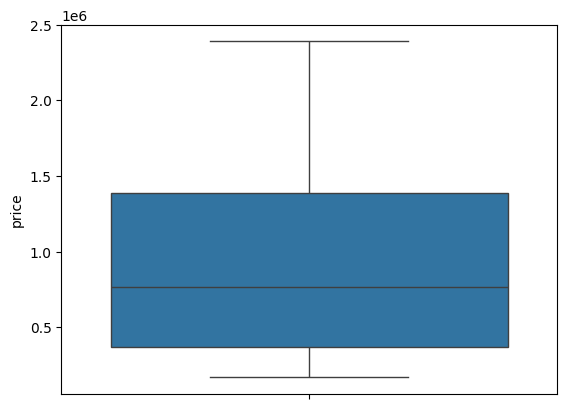

In [12]:
sns.boxplot(cars['price'])
plt.show()

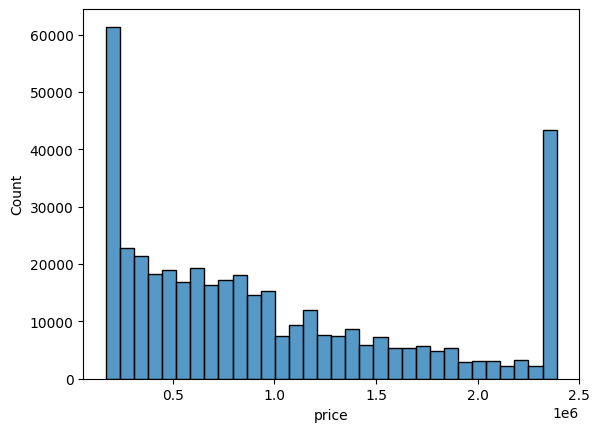

In [13]:
sns.histplot(cars['price'], bins=32)
plt.show()

In [14]:
cars['price'].describe()

count    4.132900e+05
mean     9.630415e+05
std      7.090169e+05
min      1.700000e+05
25%      3.700000e+05
50%      7.650000e+05
75%      1.390000e+06
max      2.389070e+06
Name: price, dtype: float64

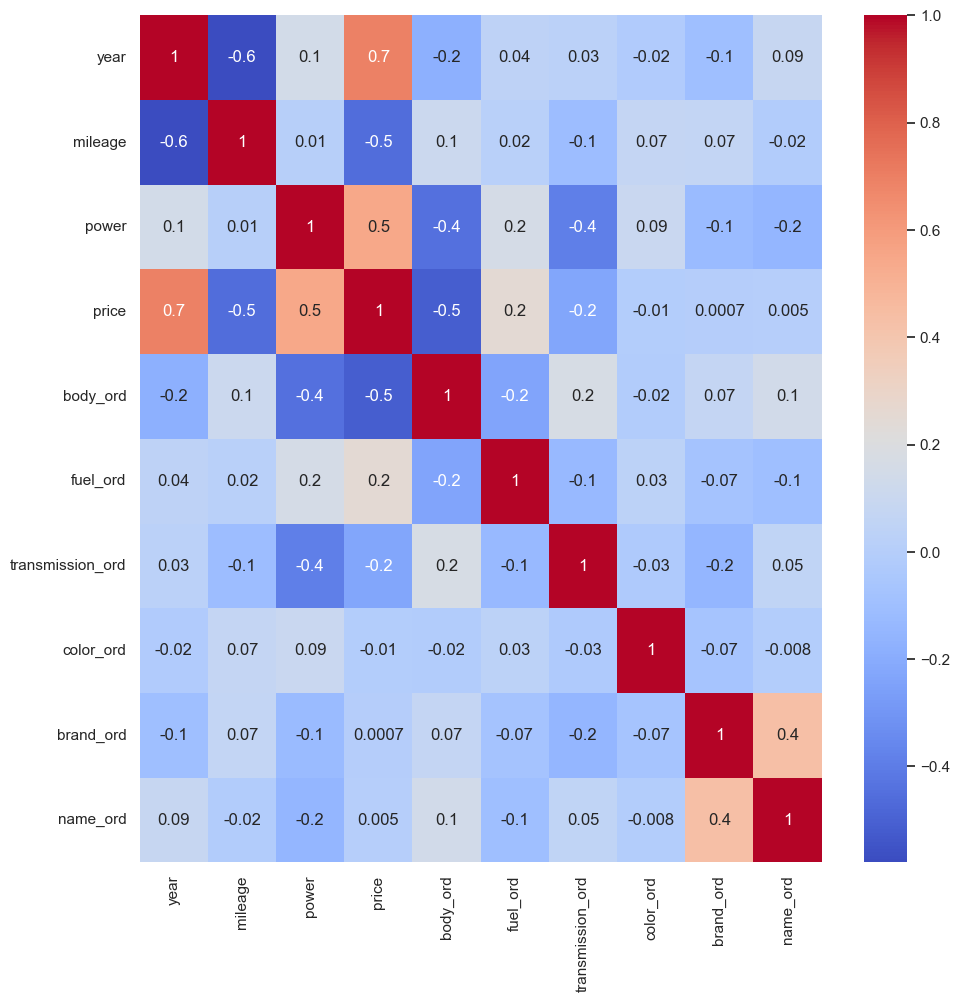

In [15]:
sns.set_theme(rc={'figure.figsize': (11, 11)})
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.1g')
plt.show()

In [16]:
# sns.pairplot(cars, x_vars=['price'], aspect=2)
# plt.show()

In [17]:
# X = cars.drop(columns=['price'])
# y = cars['price']

# # scaler = StandardScaler()
# # X = scaler.fit_transform(X)
# # joblib.dump(scaler, '../model/scaler.joblib')

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# model = xgb.XGBRegressor(
#     objective='reg:squarederror',
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=12,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.05,
#     reg_lambda=0.05,
#     random_state=42,
#     n_jobs=-1
# )

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=100
# )

# y_pred = model.predict(X_test)  # TransformedTargetRegressor вернёт предсказание в исходной шкале (expm1)
# rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
# mae_test = mean_absolute_error(y_test, y_pred)
# r2_test = r2_score(y_test, y_pred)

# print(f"Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.4f}")

In [18]:
X = cars.drop(columns=['price'])
y = cars['price']

scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, '../model/scaler.joblib')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.06,
    max_depth=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.05,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=100
)

y_pred = np.expm1(model.predict(X_test))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.4f}")

[0]	validation_0-rmse:0.79136
[100]	validation_0-rmse:0.16527
[200]	validation_0-rmse:0.16459
[299]	validation_0-rmse:0.16518
Test RMSE: 123958.16, MAE: 74321.29, R2: 0.9695


In [19]:
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [5, 7, 10, 12, 15],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.6, 0.7, 0.8, 0.9],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
#     # 'reg_alpha': [0.01, 0.05, 0.1],
#     # 'reg_lambda': [0.01, 0.05, 0.1]
# }

# model_obj = xgb.XGBRegressor(
#     objective='reg:squarederror',
#     random_state=42,
#     n_jobs=-1
# )

# try:
#     scoring = 'neg_root_mean_squared_error'
# except Exception:
#     from sklearn.metrics import mean_squared_error
#     scoring = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

# model = HalvingGridSearchCV(
#     estimator=model_obj,
#     param_grid=param_grid,
#     scoring=scoring,
#     cv=3,                # 3-fold CV (можно увеличить до 5)
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# total_tasks = len(list(ParameterGrid(param_grid))) * 3
# with tqdm_joblib(tqdm(desc="GridSearchCV", total=total_tasks)) as progress_bar:
#     model.fit(X_train, y_train)


# best_params = model.best_params_
# best_score = model.best_score_
# print("Best params:", best_params)
# print("Best CV RMSE (approx):", best_score)

In [20]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              413290 non-null  int64  
 1   mileage           413290 non-null  float64
 2   power             413290 non-null  float64
 3   price             413290 non-null  float64
 4   body_ord          413290 non-null  float64
 5   fuel_ord          413290 non-null  float64
 6   transmission_ord  413290 non-null  float64
 7   color_ord         413290 non-null  float64
 8   brand_ord         413290 non-null  int64  
 9   name_ord          413290 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 31.5 MB


In [21]:
import joblib


joblib.dump(model, '../model/xgb_regressor.joblib')

['../model/xgb_regressor.joblib']